In [141]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter

# ═══════════════════════════════════════════════════════════════════════════════
# CONSTANTS
# ═══════════════════════════════════════════════════════════════════════════════
DT           = 0.1    # sampling interval (s)
FS           = 10.0   # sampling rate (Hz)
POLYORDER    = 3      # SG polynomial order
WINDOW_S     = 5.0    # SG window length (s) — confirmed from elbow plot
EXCL_BUFFER  = 60     # seconds to exclude around moderate/major gaps

# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 1 — LOAD & BASIC FEATURES
# ═══════════════════════════════════════════════════════════════════════════════
df = pd.read_csv('finland_2019_01.csv')
df.columns = ['timestamp', 'delta_f_mHz']
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

df['delta_f_Hz'] = df['delta_f_mHz'] / 1000.0
df['frequency']  = 50.0 + df['delta_f_Hz']

print("DataFrame shape:", df.shape)
print("Time span:", df.index.min(), "→", df.index.max())
display(df.head())
display(df.tail())



DataFrame shape: (26783991, 3)
Time span: 2019-01-01 00:00:00 → 2019-01-31 23:59:59


,delta_f_mHz,delta_f_Hz,frequency
timestamp,,,
2019-01-01 00:00:00.000,100.0,0.100,50.100
2019-01-01 00:00:00.100,100.0,0.100,50.100
2019-01-01 00:00:00.200,100.0,0.100,50.100
2019-01-01 00:00:00.300,99.0,0.099,50.099
2019-01-01 00:00:00.400,99.0,0.099,50.099


,delta_f_mHz,delta_f_Hz,frequency
timestamp,,,
2019-01-31 23:59:58.600,99.0,0.099,50.099
2019-01-31 23:59:58.700,99.0,0.099,50.099
2019-01-31 23:59:58.800,100.0,0.100,50.100
2019-01-31 23:59:58.900,99.0,0.099,50.099
2019-01-31 23:59:59.000,99.0,0.099,50.099


In [142]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 2 — MISSING DATA: CLASSIFY, INTERPOLATE, MASK
# ═══════════════════════════════════════════════════════════════════════════════
nan_mask = df['delta_f_Hz'].isna()
run_id   = (nan_mask != nan_mask.shift()).cumsum()

nan_runs_info = (
    df[nan_mask]
    .groupby(run_id[nan_mask])
    .agg(
        gap_start=('delta_f_Hz', lambda x: x.index.min()),
        gap_end  =('delta_f_Hz', lambda x: x.index.max()),
        gap_len  =('delta_f_Hz', 'size')
    )
    .reset_index(drop=True)
)

def classify_gap(n):
    if n <= 10:   return 'minor'     # ≤ 1 s    — interpolate, no flag
    elif n <= 100: return 'moderate' # 1–10 s   — interpolate, flag window
    else:          return 'major'    # > 10 s   — real outage, exclude

nan_runs_info['severity'] = nan_runs_info['gap_len'].apply(classify_gap)

print("\nMissing values:", nan_mask.sum())
print("\nGap size distribution:")
print(pd.cut(nan_runs_info['gap_len'], bins=[0,1,5,10,50,100,500,2000])
      .value_counts().sort_index())
print("\nGap severity summary:")
print(nan_runs_info['severity'].value_counts())
print("\nMajor gaps (excluded from estimation):")
print(nan_runs_info[nan_runs_info['severity'] == 'major']
      [['gap_start', 'gap_end', 'gap_len']])

# Interpolate ALL gaps first — SG filter requires no NaNs
df['delta_f_Hz'] = df['delta_f_Hz'].interpolate(method='linear')
df['frequency']  = 50.0 + df['delta_f_Hz']




Missing values: 29207

Gap size distribution:
gap_len
(0, 1]         1726
(1, 5]          767
(5, 10]         168
(10, 50]        444
(50, 100]        36
(100, 500]       46
(500, 2000]       1
Name: count, dtype: int64

Gap severity summary:
severity
minor       2661
moderate     480
major         47
Name: count, dtype: int64

Major gaps (excluded from estimation):
                   gap_start                 gap_end  gap_len
155  2019-01-04 10:33:12.500 2019-01-04 10:33:23.400      110
174  2019-01-04 22:33:44.900 2019-01-04 22:33:55.700      109
206  2019-01-05 16:25:29.900 2019-01-05 16:25:41.000      112
244  2019-01-05 22:33:34.800 2019-01-05 22:34:01.700      270
246  2019-01-06 10:33:10.700 2019-01-06 10:33:23.700      131
277  2019-01-06 22:33:36.600 2019-01-06 22:34:05.000      285
297  2019-01-07 00:22:57.000 2019-01-07 00:23:08.000      111
342  2019-01-07 07:57:57.000 2019-01-07 07:58:07.900      110
410  2019-01-07 22:34:53.900 2019-01-07 22:35:08.200      144
523  2019-

In [143]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 3 — SG FILTER: SMOOTHED Δf AND ROCOF
# (runs on fully interpolated series — no NaNs)
# ═══════════════════════════════════════════════════════════════════════════════
half = round(WINDOW_S * FS / 2)
wlen = 2 * half + 1  # 51 samples = 5.1 s

print(f"\nSG filter: window = {wlen} samples = {wlen * DT:.1f} s | polyorder = {POLYORDER}")

arr = df['delta_f_Hz'].values.astype(float)

df['delta_f_smooth'] = savgol_filter(arr, window_length=wlen,
                                      polyorder=POLYORDER, deriv=0, delta=DT)
df['rocof_Hz_per_s']  = savgol_filter(arr, window_length=wlen,
                                      polyorder=POLYORDER, deriv=1, delta=DT)

# Mark unreliable windows (±EXCL_BUFFER around moderate/major gaps)
# Done AFTER SG so the filter itself always has clean input
df['reliable'] = True
for _, row in nan_runs_info[nan_runs_info['severity'].isin(['moderate','major'])].iterrows():
    buf = pd.Timedelta(seconds=EXCL_BUFFER)
    df.loc[row['gap_start'] - buf : row['gap_end'] + buf, 'reliable'] = False

print(f"\nReliable samples: {df['reliable'].sum():,} / {len(df):,}"
      f" ({df['reliable'].mean()*100:.2f}%)")

print("\nRoCoF summary (Hz/s):")
print(df['rocof_Hz_per_s'].describe(
    percentiles=[0.001, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999]))

# ── Reliable subset (used for all estimation downstream) ──────────────────
df_reliable = df[df['reliable']].copy()
print(f"\ndf_reliable shape: {df_reliable.shape}")




SG filter: window = 51 samples = 5.1 s | polyorder = 3

Reliable samples: 26,348,522 / 26,783,991 (98.37%)

RoCoF summary (Hz/s):
count    2.678399e+07
mean    -9.170621e-11
std      1.846796e-03
min     -3.038876e-02
0.1%    -6.187870e-03
1%      -4.375530e-03
5%      -3.003080e-03
25%     -1.209308e-03
50%     -5.794975e-06
75%      1.200793e-03
95%      3.021365e-03
99%      4.463058e-03
99.9%    6.376127e-03
max      3.618412e-02
Name: rocof_Hz_per_s, dtype: float64

df_reliable shape: (26348522, 6)


/var/folders/wk/smqrf7z97xvg0rhv6cm0hsn00000gn/T/ipykernel_79905/3019230013.py:11: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
/Users/macbookair/.local/share/virtualenvs/Frequency_Stability-v5D_102U/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


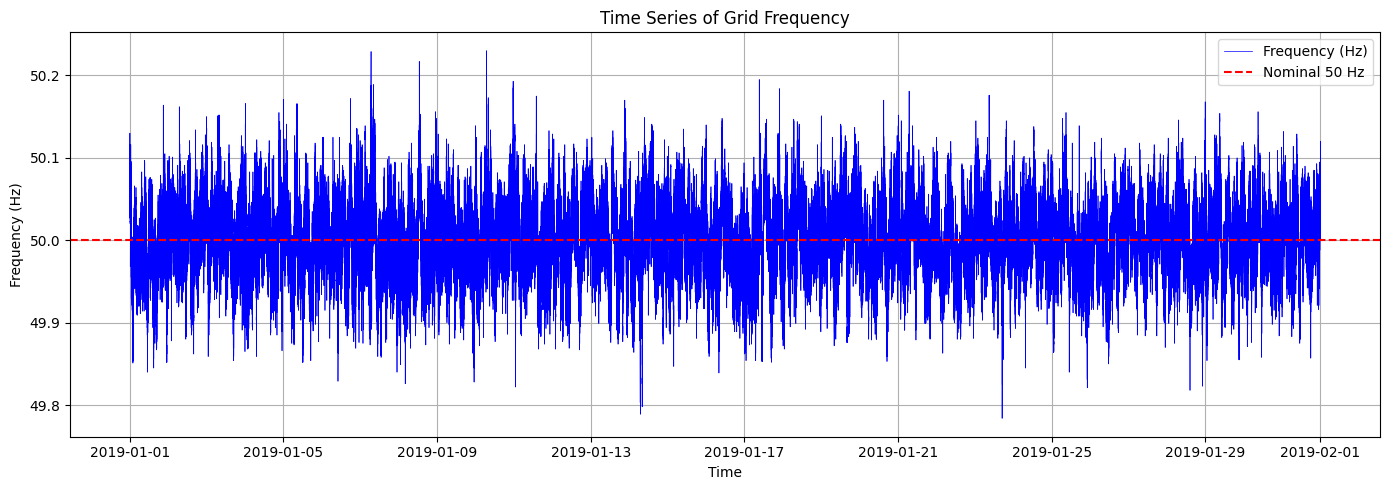

/var/folders/wk/smqrf7z97xvg0rhv6cm0hsn00000gn/T/ipykernel_79905/3019230013.py:24: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout(); plt.show()


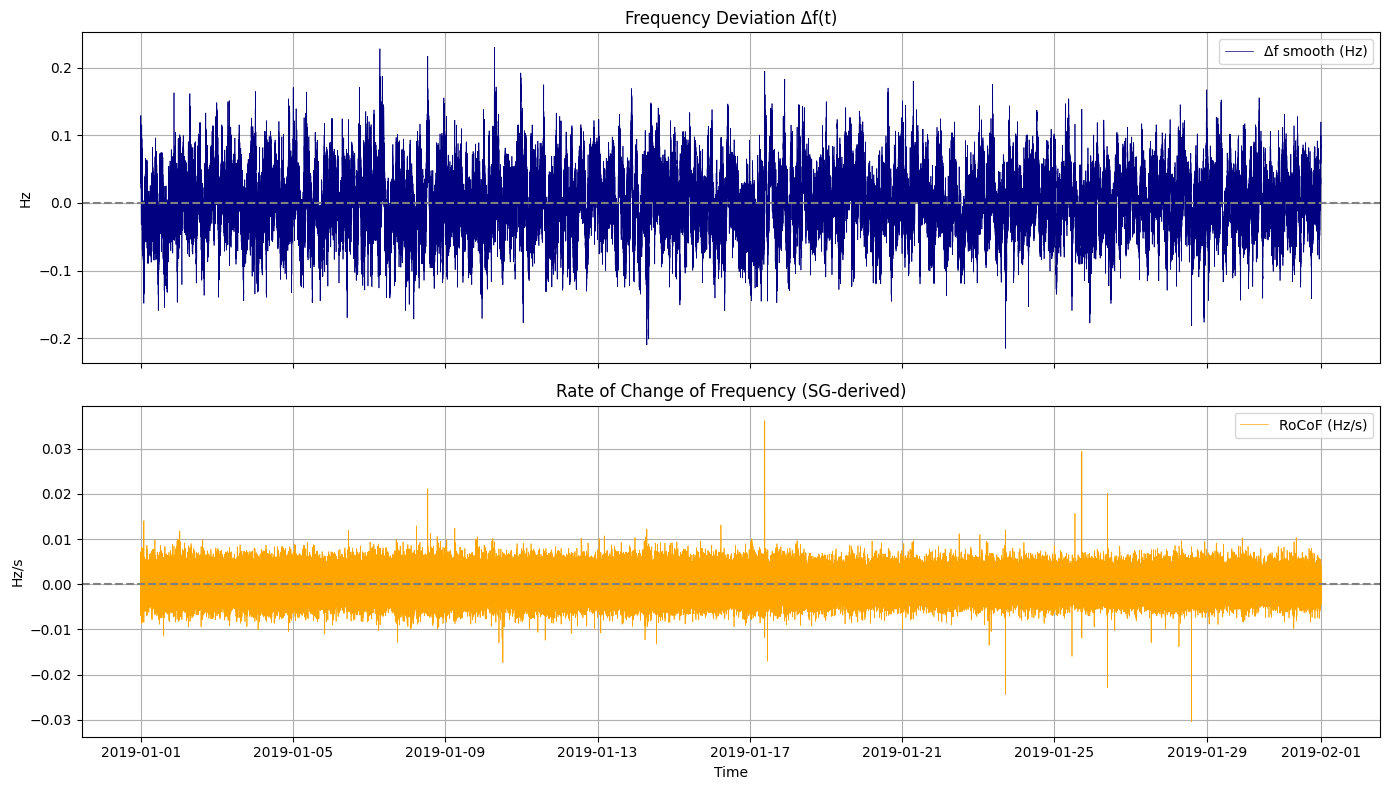


Summary statistics – frequency deviation (Hz):
count    2.678399e+07
mean    -7.537101e-05
std      4.322857e-02
min     -2.160000e-01
0.1%    -1.340000e-01
1%      -9.900000e-02
5%      -7.000000e-02
25%     -2.900000e-02
50%      0.000000e+00
75%      2.900000e-02
95%      7.100000e-02
99%      1.010000e-01
99.9%    1.440000e-01
max      2.300000e-01
Name: delta_f_Hz, dtype: float64

Skewness: 0.047349429909459534  | Kurtosis: 0.09613888814608007

Share of time outside deviation bands:
  |Δf| > 0.01 Hz: 80.8415%  (~21,652,576 samples)
  |Δf| > 0.02 Hz: 63.5479%  (~17,020,668 samples)
  |Δf| > 0.05 Hz: 24.3342%  (~6,517,678 samples)
  |Δf| > 0.10 Hz: 1.9530%  (~523,080 samples)
  |Δf| > 0.20 Hz: 0.0032%  (~845 samples)


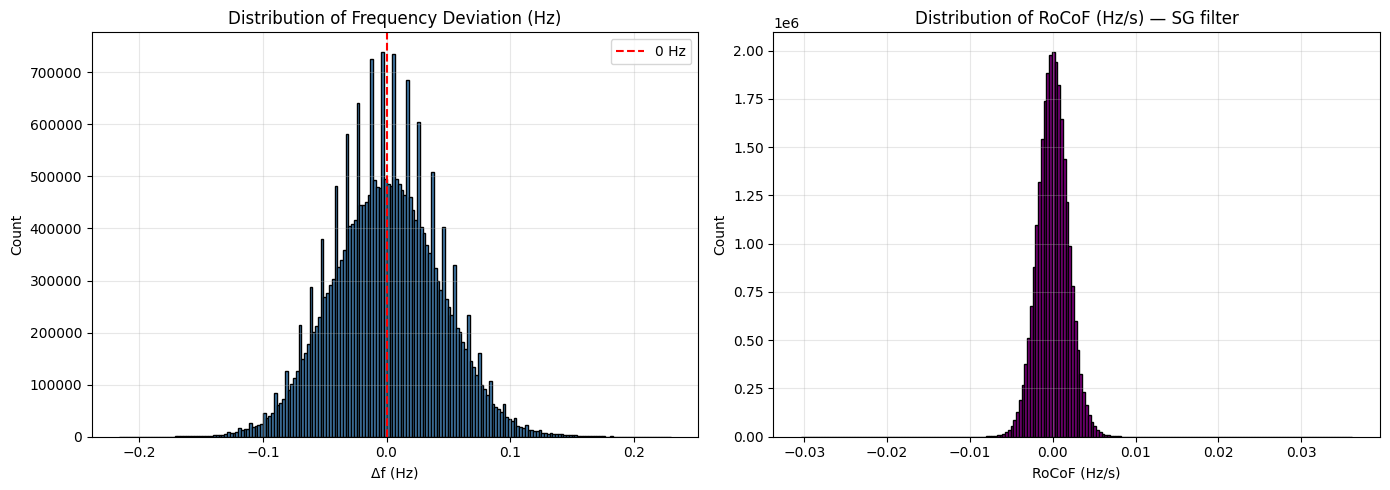

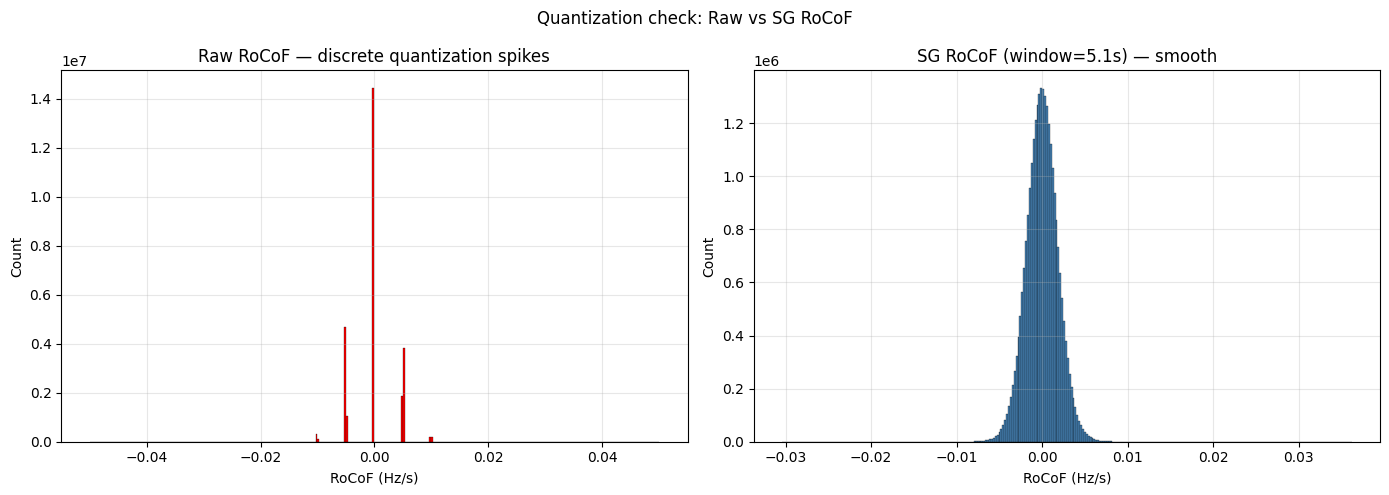

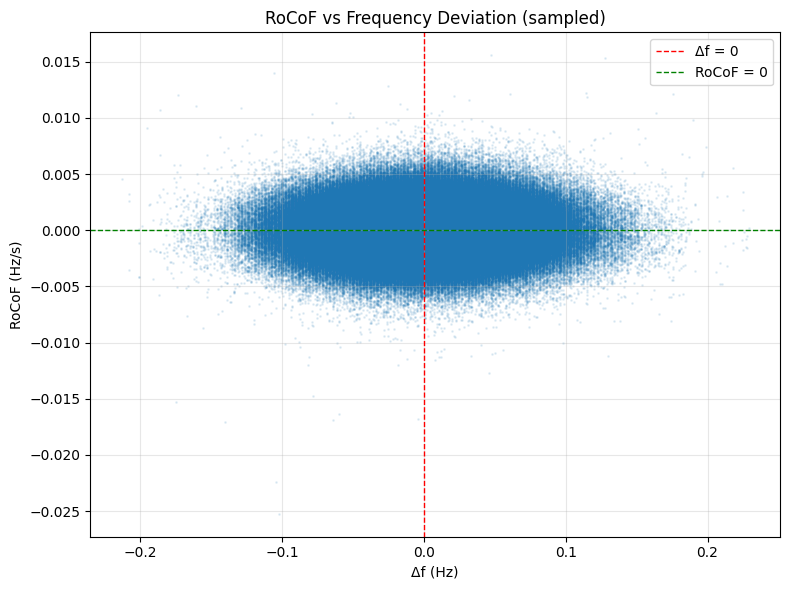

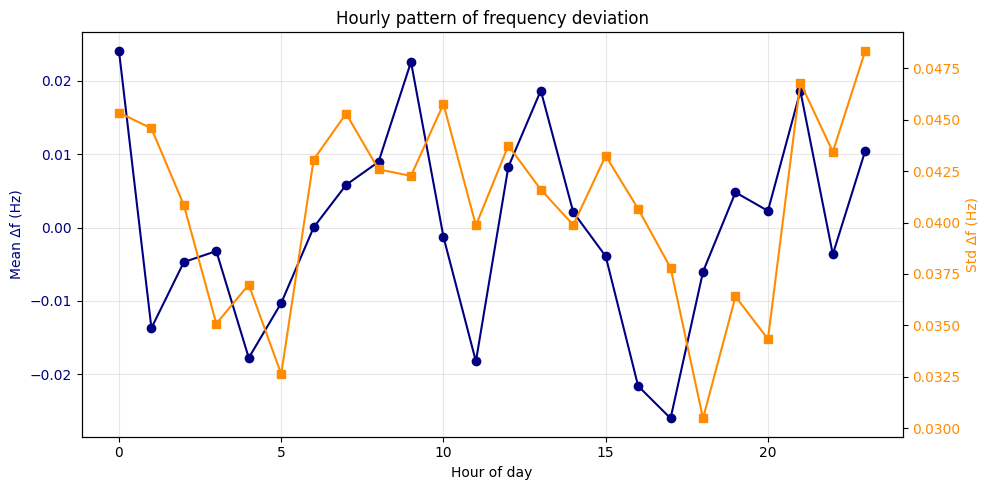

In [144]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 4 — EDA PLOTS
# ═══════════════════════════════════════════════════════════════════════════════

# ── 4a: Frequency time series ─────────────────────────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['frequency'], color='blue', linewidth=0.5, label='Frequency (Hz)')
plt.axhline(50, color='red', linestyle='--', label='Nominal 50 Hz')
plt.title("Time Series of Grid Frequency")
plt.xlabel("Time"); plt.ylabel("Frequency (Hz)")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# ── 4b: Δf and RoCoF time series (full month) ────────────────────────────
fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axs[0].plot(df.index, df['delta_f_smooth'], color='navy', linewidth=0.5, label='Δf smooth (Hz)')
axs[0].axhline(0, linestyle='--', color='gray')
axs[0].set_title('Frequency Deviation Δf(t)')
axs[0].set_ylabel('Hz'); axs[0].grid(True); axs[0].legend()
axs[1].plot(df.index, df['rocof_Hz_per_s'], color='orange', linewidth=0.5, label='RoCoF (Hz/s)')
axs[1].axhline(0, linestyle='--', color='gray')
axs[1].set_title('Rate of Change of Frequency (SG-derived)')
axs[1].set_ylabel('Hz/s'); axs[1].set_xlabel('Time')
axs[1].grid(True); axs[1].legend()
plt.tight_layout(); plt.show()

# ── 4c: Summary statistics ────────────────────────────────────────────────
pcts = [0.001, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999]
print("\nSummary statistics – frequency deviation (Hz):")
print(df['delta_f_Hz'].describe(percentiles=pcts))
print("\nSkewness:", df['delta_f_Hz'].skew(), " | Kurtosis:", df['delta_f_Hz'].kurt())

bands_Hz = [0.01, 0.02, 0.05, 0.10, 0.20]
N = len(df)
print("\nShare of time outside deviation bands:")
for band in bands_Hz:
    frac = (df['delta_f_Hz'].abs() > band).mean()
    print(f"  |Δf| > {band:.2f} Hz: {frac*100:6.4f}%  (~{int(frac*N):,} samples)")

# ── 4d: Distributions ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['delta_f_Hz'].dropna(), bins=200, color='steelblue', edgecolor='black')
axes[0].axvline(0, color='red', linestyle='--', label='0 Hz')
axes[0].set_title('Distribution of Frequency Deviation (Hz)')
axes[0].set_xlabel('Δf (Hz)'); axes[0].set_ylabel('Count')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].hist(df['rocof_Hz_per_s'], bins=200, color='purple', edgecolor='black')
axes[1].set_title('Distribution of RoCoF (Hz/s) — SG filter')
axes[1].set_xlabel('RoCoF (Hz/s)'); axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ── 4e: Quantization check — raw diff vs SG ──────────────────────────────
rocof_raw = np.gradient(arr, DT)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
clip = 0.05
axes[0].hist(np.clip(rocof_raw, -clip, clip), bins=300,
             color='red', edgecolor='black', linewidth=0.2)
axes[0].set_title('Raw RoCoF — discrete quantization spikes')
axes[0].set_xlabel('RoCoF (Hz/s)'); axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)
axes[1].hist(np.clip(df['rocof_Hz_per_s'].values, -clip, clip), bins=300,
             color='steelblue', edgecolor='black', linewidth=0.2)
axes[1].set_title(f'SG RoCoF (window={wlen*DT:.1f}s) — smooth')
axes[1].set_xlabel('RoCoF (Hz/s)'); axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)
plt.suptitle('Quantization check: Raw vs SG RoCoF', fontsize=12)
plt.tight_layout(); plt.show()

# ── 4f: RoCoF vs Δf scatter (sampled) ────────────────────────────────────
max_pts = 1_000_000
scatter_sample = (df.sample(n=max_pts, random_state=1)
                  if len(df) > max_pts else df)
plt.figure(figsize=(8, 6))
plt.scatter(scatter_sample['delta_f_Hz'], scatter_sample['rocof_Hz_per_s'],
            s=1, alpha=0.1)
plt.axvline(0, color='red',   linestyle='--', linewidth=1, label='Δf = 0')
plt.axhline(0, color='green', linestyle='--', linewidth=1, label='RoCoF = 0')
plt.xlabel('Δf (Hz)'); plt.ylabel('RoCoF (Hz/s)')
plt.title('RoCoF vs Frequency Deviation (sampled)')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# ── 4g: Hourly pattern ────────────────────────────────────────────────────
max_pts_hourly = 1_000_000
sample_hourly  = (df.sample(n=max_pts_hourly, random_state=0).sort_index()
                  if len(df) > max_pts_hourly else df.copy())
sample_hourly['hour'] = sample_hourly.index.hour
hourly_stats = sample_hourly.groupby('hour')['delta_f_Hz'].agg(['mean','std'])
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(hourly_stats.index, hourly_stats['mean'], marker='o',
         color='navy', label='Mean Δf (Hz)')
ax1.set_xlabel('Hour of day'); ax1.set_ylabel('Mean Δf (Hz)', color='navy')
ax1.tick_params(axis='y', labelcolor='navy'); ax1.grid(True, alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(hourly_stats.index, hourly_stats['std'], marker='s',
         color='darkorange', label='Std Δf (Hz)')
ax2.set_ylabel('Std Δf (Hz)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
plt.title('Hourly pattern of frequency deviation')
fig.tight_layout(); plt.show()



In [145]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 5 — ANOMALY SUMMARY (regulatory tracking only)
# ═══════════════════════════════════════════════════════════════════════════════
FREQ_THRESH  = 0.2   # Hz   — Nordic FCR regulatory band
ROCOF_THRESH = 0.02  # Hz/s — tuned to SG RoCoF scale

df_reliable['anomaly_freq']  = df_reliable['delta_f_Hz'].abs()    > FREQ_THRESH
df_reliable['anomaly_rocof'] = df_reliable['rocof_Hz_per_s'].abs() > ROCOF_THRESH
df_reliable['anomaly_any']   = df_reliable['anomaly_freq'] | df_reliable['anomaly_rocof']

N_rel = len(df_reliable)
print(f"\nAnomaly summary (reliable data only, N={N_rel:,}):")
print(f"  Frequency  anomalies |Δf|>{FREQ_THRESH} Hz   : "
      f"{df_reliable['anomaly_freq'].sum():,} ({df_reliable['anomaly_freq'].mean()*100:.4f}%)")
print(f"  RoCoF      anomalies |R|>{ROCOF_THRESH} Hz/s : "
      f"{df_reliable['anomaly_rocof'].sum():,} ({df_reliable['anomaly_rocof'].mean()*100:.4f}%)")
print(f"  Any anomaly                             : "
      f"{df_reliable['anomaly_any'].sum():,} ({df_reliable['anomaly_any'].mean()*100:.4f}%)")

# Threshold scan — useful for deciding threshold for other months
thresholds = [0.05, 0.10, 0.15, 0.20, 0.25]
print(f"\n{'Threshold':>12} {'Crossings':>12} {'% time':>10}")
print("-" * 38)
for t in thresholds:
    outside   = df_reliable['delta_f_Hz'].abs() > t
    crossings = outside.ne(outside.shift()).cumsum()
    n_events  = outside[outside].groupby(crossings[outside]).ngroups if outside.any() else 0
    pct       = outside.mean() * 100
    print(f"  |Δf| > {t:.2f} Hz   {n_events:>10}   {pct:>9.4f}%")




Anomaly summary (reliable data only, N=26,348,522):
  Frequency  anomalies |Δf|>0.2 Hz   : 845 (0.0032%)
  RoCoF      anomalies |R|>0.02 Hz/s : 138 (0.0005%)
  Any anomaly                             : 983 (0.0037%)

   Threshold    Crossings     % time
--------------------------------------
  |Δf| > 0.05 Hz        41177     24.3070%
  |Δf| > 0.10 Hz         4822      1.9531%
  |Δf| > 0.15 Hz          267      0.1032%
  |Δf| > 0.20 Hz            8      0.0032%
  |Δf| > 0.25 Hz            0      0.0000%


In [146]:

# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 6 — DISTURBANCE EVENT DETECTION (for H/D estimation)
#
# Trigger : |Δf| > FREQ_THRESH (0.2 Hz) — Nordic FCR regulatory band
# Onset   : traced back up to PRE_SEARCH_S before crossing, to where RoCoF
#            first exceeded 3σ (0.006 Hz/s) — marks true physical disturbance start
# Peak    : largest |Δf| in POST_WINDOW_S after onset
# End     : first sample after peak where |Δf| drops below 0.05 Hz (recovery)
# Merge   : crossings < MIN_EVENT_GAP_S apart → same physical event
#
# Classification requires BOTH:
#   (1) peak RoCoF exceeds threshold (magnitude check)
#   (2) peak RoCoF occurs within ROCOF_LAG_MAX_S of onset (shape check)
#       → eliminates slow drift events where a noisy patch happens to exceed
#         the RoCoF threshold far from the onset
#
# Columns produced: onset_time, peak_time, peak_rocof_time, end_time,
#                   direction, peak_df_Hz, max_rocof_Hz_s,
#                   rocof_lag_s, duration_s, classification
# ═══════════════════════════════════════════════════════════════════════════════
MIN_EVENT_GAP_S  = 300   # seconds — merge crossings closer than this
PRE_SEARCH_S     = 30    # seconds to look back before crossing for true onset
POST_WINDOW_S    = 300   # seconds to look forward after crossing
ROCOF_LAG_MAX_S  = 10    # seconds — peak RoCoF must occur within this of onset

outside       = df_reliable['delta_f_Hz'].abs() > FREQ_THRESH
state_change  = outside & ~outside.shift(fill_value=False)  # rising edges only
raw_crossings = df_reliable[state_change].index.tolist()

# ── Merge crossings belonging to the same physical event ──────────────────
merged_crossings = [raw_crossings[0]]
for t in raw_crossings[1:]:
    if (t - merged_crossings[-1]).total_seconds() > MIN_EVENT_GAP_S:
        merged_crossings.append(t)

print(f"\nRaw threshold crossings : {len(raw_crossings)}")
print(f"Merged physical events  : {len(merged_crossings)}")

# ── Classifier: magnitude + shape ─────────────────────────────────────────
def classify_event(row):
    rocof_lag = (row['peak_rocof_time'] - row['onset_time']).total_seconds()
    if row['max_rocof_Hz_s'] > 0.015 and rocof_lag < ROCOF_LAG_MAX_S:
        return 'STRONG'
    elif row['max_rocof_Hz_s'] > 0.008 and rocof_lag < ROCOF_LAG_MAX_S:
        return 'MODERATE'
    else:
        return 'WEAK'

# ── Build segment records ──────────────────────────────────────────────────
seg_records = []
for t in merged_crossings:
    pre_start = t - pd.Timedelta(seconds=PRE_SEARCH_S)
    post_end  = t + pd.Timedelta(seconds=POST_WINDOW_S)
    window    = df_reliable.loc[pre_start:post_end]
    if len(window) == 0:
        continue

    # True onset: trace back before crossing to first RoCoF > 3σ (0.006 Hz/s)
    pre_window  = df_reliable.loc[pre_start:t]
    rocof_above = pre_window['rocof_Hz_per_s'].abs() > 0.006
    onset_time  = pre_window[rocof_above].index[0] if rocof_above.any() else t

    # Peak Δf: largest |Δf| in window after onset
    post_onset      = window.loc[onset_time:]
    peak_idx        = post_onset['delta_f_Hz'].abs().idxmax()
    peak_df         = post_onset.loc[peak_idx, 'delta_f_Hz']
    direction       = 'under-frequency' if peak_df < 0 else 'over-frequency'

    # Peak RoCoF and its timing (used for shape-based classification)
    peak_rocof      = window['rocof_Hz_per_s'].abs().max()
    peak_rocof_time = window['rocof_Hz_per_s'].abs().idxmax()
    rocof_lag       = (peak_rocof_time - onset_time).total_seconds()

    # End: first sample after peak where |Δf| has recovered by 50% of peak
    # End: 50% recovery from peak, or local minimum within 60s of peak
    peak_abs      = abs(peak_df)
    post_peak     = post_onset.loc[peak_idx:]
    post_peak_60s = post_peak.iloc[:int(60/ DT)]   # first 60s after peak only

    recovery = post_peak[post_peak['delta_f_Hz'].abs() < peak_abs * 0.5]

    if len(recovery) > 0:
        end_time = recovery.index[0]
    else:
        # local minimum within first 60s after peak
        end_time = post_peak_60s['delta_f_Hz'].abs().idxmin()

    duration  = (end_time - onset_time).total_seconds()

    seg_records.append({
        'onset_time'     : onset_time,
        'peak_time'      : peak_idx,
        'peak_rocof_time': peak_rocof_time,
        'end_time'       : end_time,
        'direction'      : direction,
        'peak_df_Hz'     : round(peak_df,    4),
        'max_rocof_Hz_s' : round(peak_rocof, 5),
        'rocof_lag_s'    : round(rocof_lag,  1),
        'duration_s'     : round(duration,   1),
    })

segments = pd.DataFrame(seg_records).reset_index(drop=True)
segments['classification'] = segments.apply(classify_event, axis=1)

# Estimation-grade: STRONG or MODERATE only
segments_est = segments[segments['classification'] != 'WEAK'].copy().reset_index(drop=True)

print(f"\nAll events             : {len(segments)}")
print(f"Estimation-grade       : {len(segments_est)}  (STRONG + MODERATE)")
print("\nAll events (sorted by RoCoF strength):")
display(segments.sort_values('max_rocof_Hz_s', ascending=False).reset_index(drop=True))
print("\nEstimation-grade events:")
display(segments_est)




Raw threshold crossings : 8
Merged physical events  : 6

All events             : 6
Estimation-grade       : 4  (STRONG + MODERATE)

All events (sorted by RoCoF strength):


,onset_time,peak_time,peak_rocof_time,end_time,direction,peak_df_Hz,max_rocof_Hz_s,rocof_lag_s,duration_s,classification
0,2019-01-23 17:06:02.400,2019-01-23 17:06:17.200,2019-01-23 17:06:05.000,2019-01-23 17:06:29.800,under-frequency,-0.216,0.02437,2.6,27.4,STRONG
1,2019-01-08 12:56:42.300,2019-01-08 12:56:52.800,2019-01-08 12:56:44.100,2019-01-08 13:00:14.200,over-frequency,0.217,0.02111,1.8,211.9,STRONG
2,2019-01-14 07:03:45.000,2019-01-14 07:03:48.100,2019-01-14 07:03:54.000,2019-01-14 07:04:03.800,under-frequency,-0.211,0.01218,9.0,18.8,MODERATE
3,2019-01-10 07:00:03.800,2019-01-10 07:00:32.700,2019-01-10 07:00:12.900,2019-01-10 07:02:50.200,over-frequency,0.230,0.00937,9.1,166.4,MODERATE
4,2019-01-14 08:13:48.000,2019-01-14 08:13:48.200,2019-01-14 08:15:35.300,2019-01-14 08:15:36.400,under-frequency,-0.202,0.00894,107.3,108.4,WEAK
5,2019-01-07 06:48:47.400,2019-01-07 06:48:58.400,2019-01-07 06:49:09.500,2019-01-07 06:49:28.000,over-frequency,0.229,0.00649,22.1,40.6,WEAK



Estimation-grade events:


,onset_time,peak_time,peak_rocof_time,end_time,direction,peak_df_Hz,max_rocof_Hz_s,rocof_lag_s,duration_s,classification
0,2019-01-08 12:56:42.300,2019-01-08 12:56:52.800,2019-01-08 12:56:44.100,2019-01-08 13:00:14.200,over-frequency,0.217,0.02111,1.8,211.9,STRONG
1,2019-01-10 07:00:03.800,2019-01-10 07:00:32.700,2019-01-10 07:00:12.900,2019-01-10 07:02:50.200,over-frequency,0.230,0.00937,9.1,166.4,MODERATE
2,2019-01-14 07:03:45.000,2019-01-14 07:03:48.100,2019-01-14 07:03:54.000,2019-01-14 07:04:03.800,under-frequency,-0.211,0.01218,9.0,18.8,MODERATE
3,2019-01-23 17:06:02.400,2019-01-23 17:06:17.200,2019-01-23 17:06:05.000,2019-01-23 17:06:29.800,under-frequency,-0.216,0.02437,2.6,27.4,STRONG


In [147]:
print(segments_est.columns.tolist())

['onset_time', 'peak_time', 'peak_rocof_time', 'end_time', 'direction', 'peak_df_Hz', 'max_rocof_Hz_s', 'rocof_lag_s', 'duration_s', 'classification']



--- Event 0 | STRONG | 2019-01-08 12:56:42.300000 ---


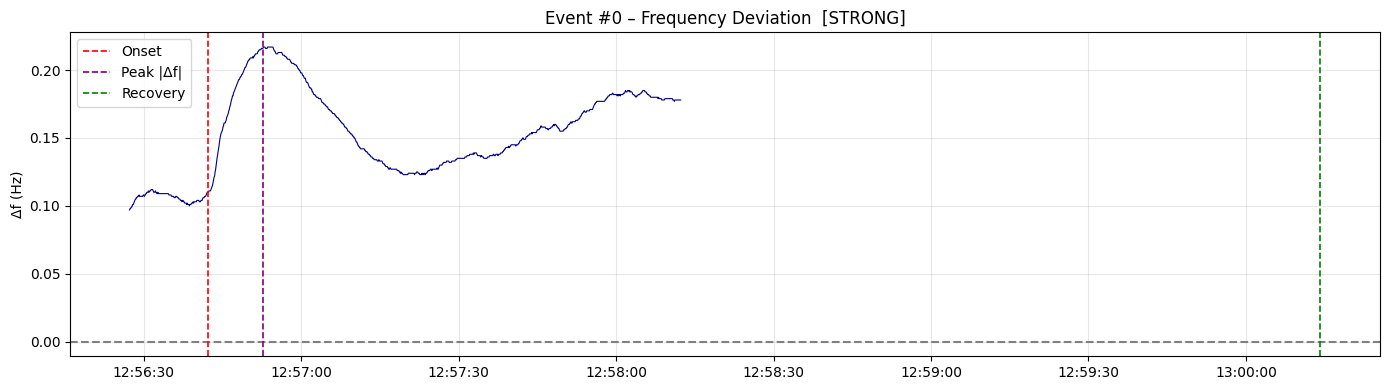

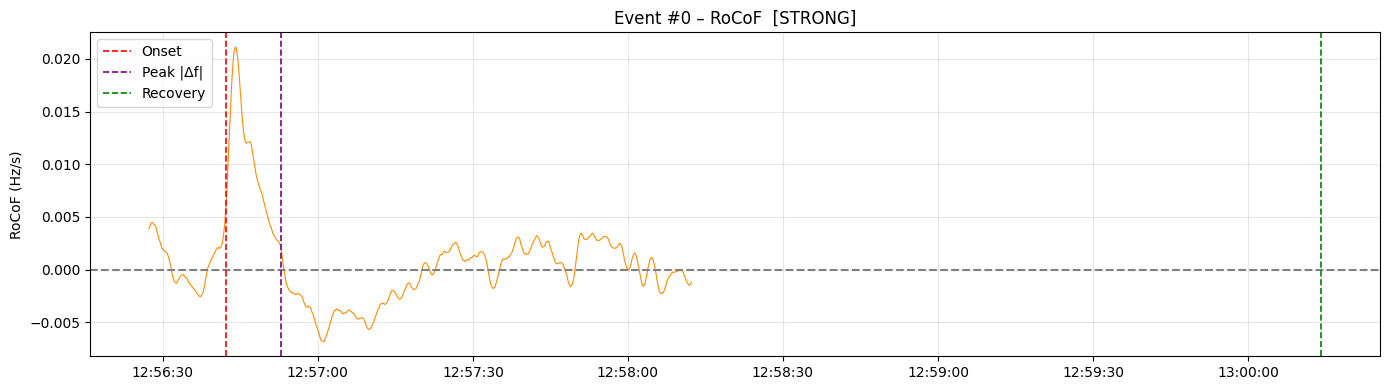


--- Event 1 | MODERATE | 2019-01-10 07:00:03.800000 ---


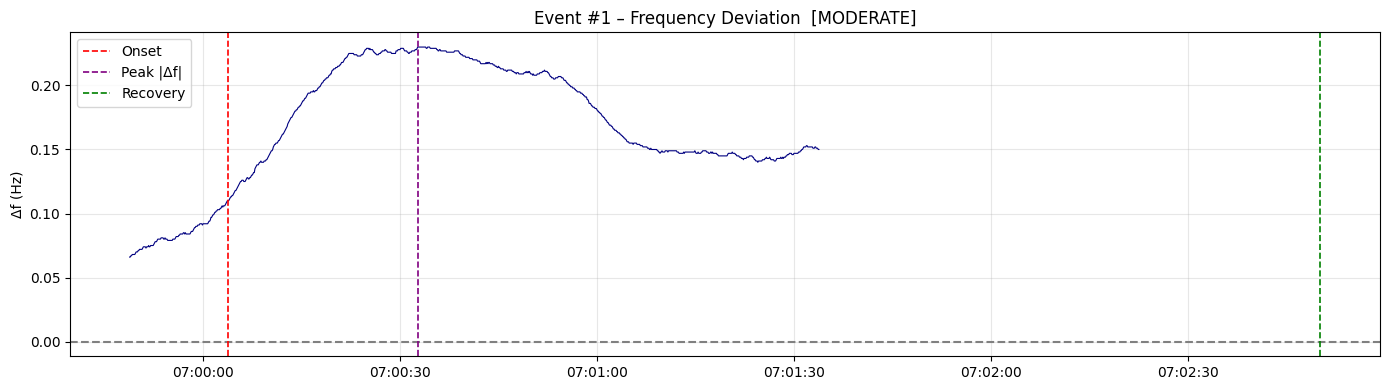

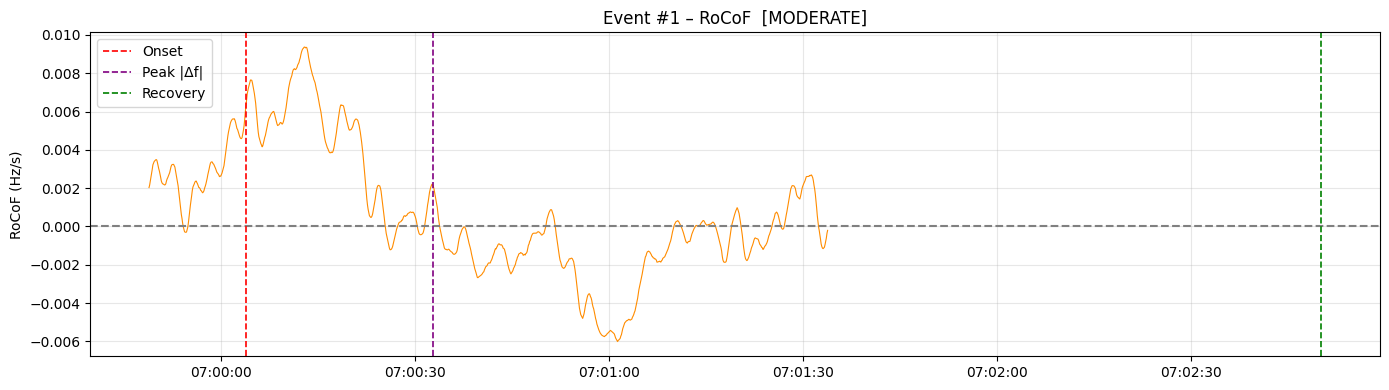


--- Event 2 | MODERATE | 2019-01-14 07:03:45 ---


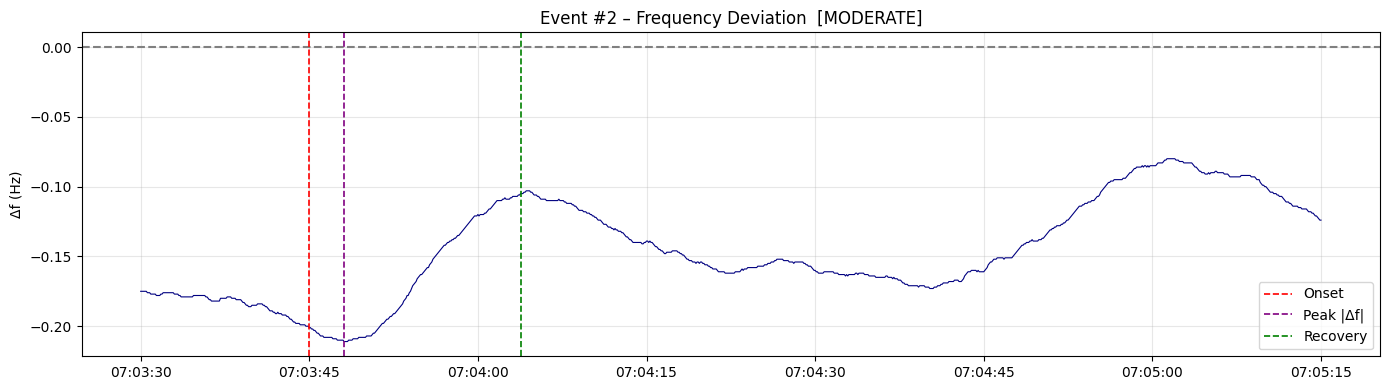

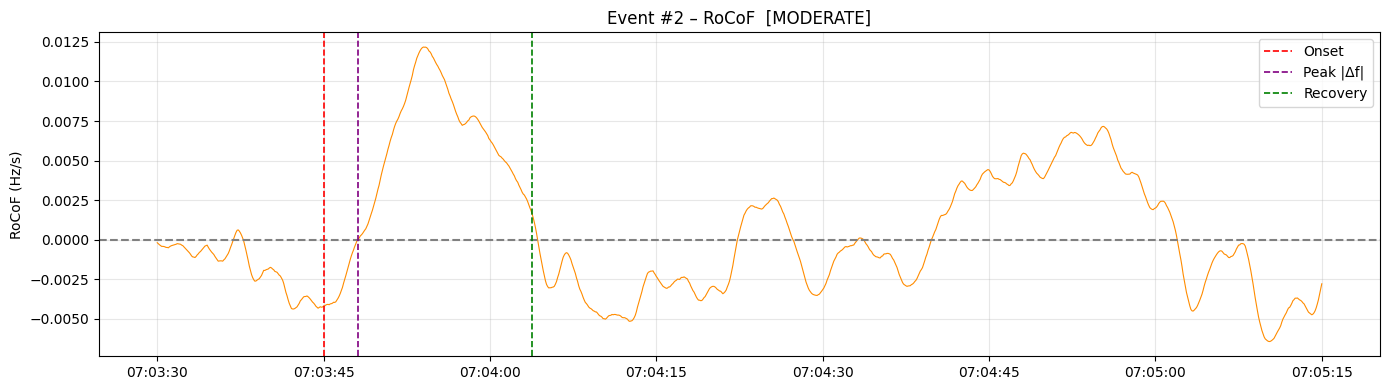


--- Event 3 | STRONG | 2019-01-23 17:06:02.400000 ---


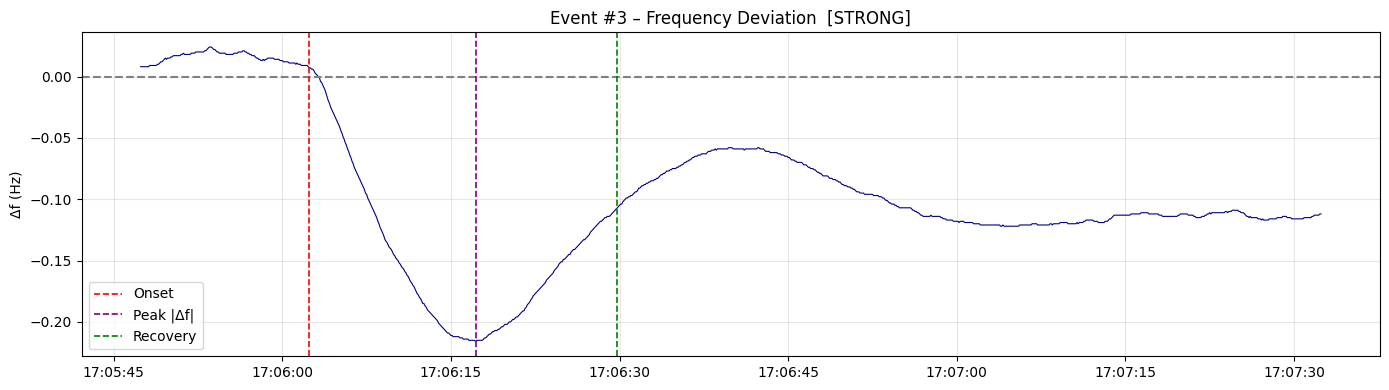

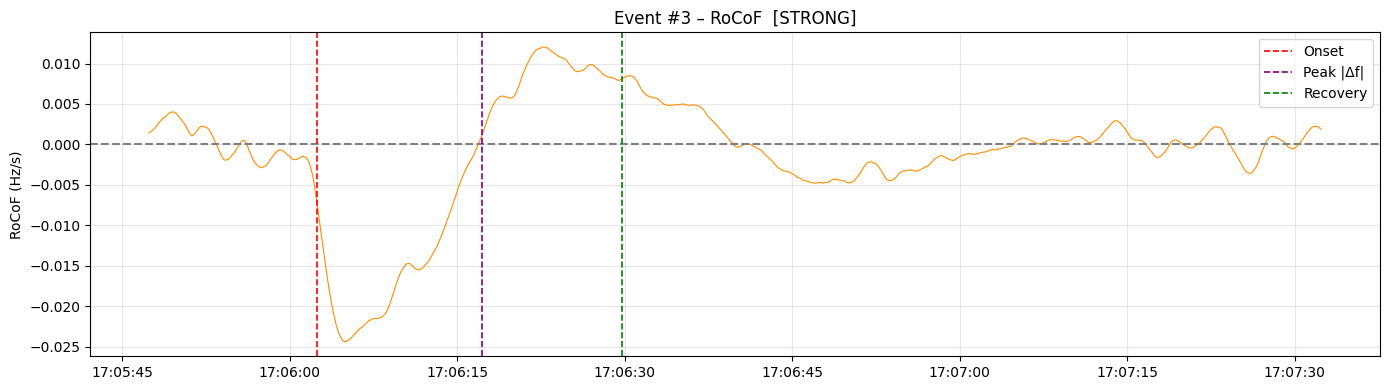

In [148]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 7 — SEGMENT INSPECTION HELPER
# ═══════════════════════════════════════════════════════════════════════════════
def plot_segment(segment_row, pre_seconds=15, post_seconds=90,
                 seg_table=None):
    """
    Plot Δf and RoCoF around an event.
    seg_table defaults to segments_est (estimation-grade events).
    Pass seg_table=segments to inspect all events including WEAK ones.
    Three vertical markers:
        red    — onset  (RoCoF precursor trace-back)
        purple — peak |Δf|
        green  — recovery (50% of peak, or local min within 60s)
    """
    if seg_table is None:
        seg_table = segments_est
    if segment_row >= len(seg_table):
        print(f"segment_row {segment_row} out of range (table has {len(seg_table)} rows)")
        return

    seg   = seg_table.iloc[segment_row]
    onset = seg['onset_time']
    peak  = seg['peak_time']
    end   = seg['end_time']
    label = seg.get('classification', '')

    window = df_reliable.loc[
        onset - pd.Timedelta(seconds=pre_seconds) :
        onset + pd.Timedelta(seconds=post_seconds)
    ]
    if len(window) == 0:
        print(f"No data in window for segment {segment_row}")
        return

    for col, color, ylabel, title in [
        ('delta_f_Hz',     'navy',       'Δf (Hz)',
         f'Event #{segment_row} – Frequency Deviation  [{label}]'),
        ('rocof_Hz_per_s', 'darkorange', 'RoCoF (Hz/s)',
         f'Event #{segment_row} – RoCoF  [{label}]'),
    ]:
        plt.figure(figsize=(14, 4))
        plt.plot(window.index, window[col], color=color, linewidth=0.8)
        plt.axhline(0, linestyle='--', color='gray')
        plt.axvline(onset, color='red',    linestyle='--', linewidth=1.2, label='Onset')
        plt.axvline(peak,  color='purple', linestyle='--', linewidth=1.2, label='Peak |Δf|')
        plt.axvline(end,   color='green',  linestyle='--', linewidth=1.2, label='Recovery')
        plt.title(title); plt.ylabel(ylabel)
        plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

# ── Visualize all estimation-grade events ────────────────────────────────
for i in range(len(segments_est)):
    print(f"\n--- Event {i} | {segments_est.iloc[i]['classification']} "
          f"| {segments_est.iloc[i]['onset_time']} ---")
    plot_segment(i, pre_seconds=15, post_seconds=90)



In [149]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 8 — OSCILLATION DETECTION  (runs on segments_est only)
# ═══════════════════════════════════════════════════════════════════════════════
from scipy.signal import find_peaks

def get_decay_window(segment_row, decay_seconds=30):
    """Return (peak_time, decay_df) starting from peak |Δf| of the event."""
    if segment_row >= len(segments_est):
        return None
    seg      = segments_est.iloc[segment_row]
    # Use peak_time directly — already computed during event detection
    peak_time = seg['peak_time']
    decay_end = peak_time + pd.Timedelta(seconds=decay_seconds)
    decay     = df_reliable.loc[peak_time:decay_end].copy()
    return (peak_time, decay) if len(decay) > 0 else None

def is_decay_oscillatory(segment_row, decay_seconds=30,
                          min_peaks=3, noise_floor=0.002):
    out = get_decay_window(segment_row, decay_seconds)
    if out is None:
        return {"oscillatory": False, "reason": "empty_segment"}
    peak_time, decay = out
    if len(decay) < 30:
        return {"oscillatory": False, "reason": "too_short"}

    t      = (decay.index - decay.index[0]).total_seconds().values
    y      = decay['delta_f_Hz'].values.copy()
    y[np.abs(y) < noise_floor] = 0.0
    p      = np.polyfit(t, y, deg=1)
    x      = y - np.polyval(p, t)
    dt_med = np.median(np.diff(t))
    prom   = np.std(x)
    if prom == 0:
        return {"oscillatory": False, "reason": "flat_signal"}

    peaks, _ = find_peaks(np.abs(x),
                           distance=max(1, int(1.0 / dt_med)),
                           prominence=prom)
    if len(peaks) < min_peaks:
        return {"oscillatory": False, "n_peaks": len(peaks),
                "reason": "not_enough_peaks"}

    amps   = np.abs(x[peaks])
    deltas = np.log(amps[:-1] / amps[1:])
    deltas = deltas[np.isfinite(deltas) & (deltas > 0)]
    if len(deltas) < 2:
        return {"oscillatory": False, "n_peaks": len(peaks),
                "reason": "no_consistent_decay"}

    return {
        "oscillatory"          : True,
        "n_peaks"              : len(peaks),
        "log_decrement_median" : np.median(deltas),
        "decay_start"          : decay.index[0],
        "decay_end"            : decay.index[-1],
    }

osc_results = [dict(is_decay_oscillatory(i), segment_row=i)
               for i in range(len(segments_est))]
osc_df = pd.DataFrame(osc_results)
print("\nOscillation summary (estimation-grade segments):")
print(osc_df["oscillatory"].value_counts())
if osc_df["oscillatory"].any():
    print("\nOscillatory segments:")
    display(osc_df[osc_df["oscillatory"]].sort_values("n_peaks", ascending=False))




Oscillation summary (estimation-grade segments):
oscillatory
False    4
Name: count, dtype: int64


In [150]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 9 — ALPHA (D/2H) ESTIMATION VIA EXPONENTIAL DECAY FIT
# ═══════════════════════════════════════════════════════════════════════════════
from scipy.stats import linregress

def _get_decay_fit_data(segment_row, decay_seconds=30,
                        start_offset_sec=0.5, noise_floor=0.002):
    """Shared helper — returns (df_fit, linregress_result, decay_start) or None.
    Uses peak_time from segments_est directly — no need to search for it again.
    """
    seg         = segments_est.iloc[segment_row]
    peak_time   = seg['peak_time']
    decay_start = peak_time + pd.Timedelta(seconds=start_offset_sec)
    decay_end   = peak_time + pd.Timedelta(seconds=decay_seconds)
    df_decay    = df_reliable.loc[decay_start:decay_end].copy()
    if len(df_decay) < 20:
        return None
    df_decay['t_sec']  = (df_decay.index - decay_start).total_seconds()
    df_decay['abs_df'] = df_decay['delta_f_Hz'].abs()
    df_fit = df_decay[df_decay['abs_df'] > noise_floor].copy()
    if len(df_fit) < 20:
        return None
    df_fit['log_abs_df'] = np.log(df_fit['abs_df'])
    res = linregress(df_fit['t_sec'], df_fit['log_abs_df'])
    return df_fit, res, decay_start

def estimate_alpha(segment_row, decay_seconds=30,
                   start_offset_sec=0.5, noise_floor=0.002):
    out = _get_decay_fit_data(segment_row, decay_seconds, start_offset_sec, noise_floor)
    if out is None:
        return None
    df_fit, res, decay_start = out
    alpha = -res.slope
    r2    = res.rvalue ** 2
    return {
        "segment_id"  : segment_row,
        "alpha"       : alpha,           # = D/(2H)
        "r2"          : r2,
        "decay_start" : decay_start,
        "decay_end"   : decay_start + pd.Timedelta(seconds=decay_seconds),
        "num_samples" : len(df_fit),
        "classification": segments_est.iloc[segment_row]['classification']
    }

def plot_decay_fit(segment_row, decay_seconds=30,
                   start_offset_sec=0.5, noise_floor=0.002):
    out = _get_decay_fit_data(segment_row, decay_seconds, start_offset_sec, noise_floor)
    if out is None:
        print("Not enough data for segment", segment_row)
        return
    df_fit, res, _ = out
    alpha  = -res.slope
    r2     = res.rvalue ** 2
    t_fit  = np.linspace(0, df_fit['t_sec'].max(), 300)
    fitted = np.exp(res.intercept - alpha * t_fit)

    plt.figure(figsize=(10, 5))
    plt.scatter(df_fit['t_sec'], df_fit['abs_df'], s=10, alpha=0.6, label='|Δf| data')
    plt.plot(t_fit, fitted, linewidth=2,
             label=f'Exp fit: α={alpha:.5f}  R²={r2:.3f}')
    plt.yscale('log')
    plt.xlabel('Time after peak (s)'); plt.ylabel('|Δf| (Hz)')
    plt.title(f'Decay Fit — Segment {segment_row}  '
              f'[{segments_est.iloc[segment_row]["classification"]}]')
    plt.grid(True, which='both', alpha=0.3); plt.legend()
    plt.tight_layout(); plt.show()
    print(f"α = D/(2H) = {alpha:.6f} 1/s  |  R² = {r2:.4f}")

decay_results = pd.DataFrame(
    [r for r in (estimate_alpha(i) for i in range(len(segments_est))) if r is not None]
)
print(f"\nAlpha estimated for {len(decay_results)} / {len(segments_est)} estimation-grade segments:")
display(decay_results)


Alpha estimated for 4 / 4 estimation-grade segments:


,segment_id,alpha,r2,decay_start,decay_end,num_samples,classification
0,0,0.023001,0.982376,2019-01-08 12:56:53.300,2019-01-08 12:57:23.300,296,STRONG
1,1,0.008894,0.861578,2019-01-10 07:00:33.200,2019-01-10 07:01:03.200,296,MODERATE
2,2,0.013902,0.315179,2019-01-14 07:03:48.600,2019-01-14 07:04:18.600,296,MODERATE
3,3,0.049636,0.892813,2019-01-23 17:06:17.700,2019-01-23 17:06:47.700,296,STRONG



--- Decay fit: Event 0 ---


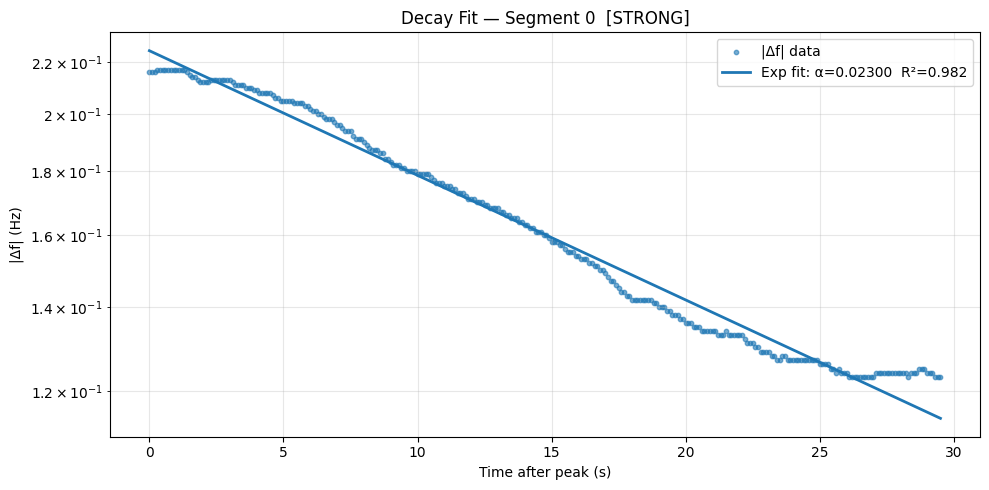

α = D/(2H) = 0.023001 1/s  |  R² = 0.9824

--- Decay fit: Event 1 ---


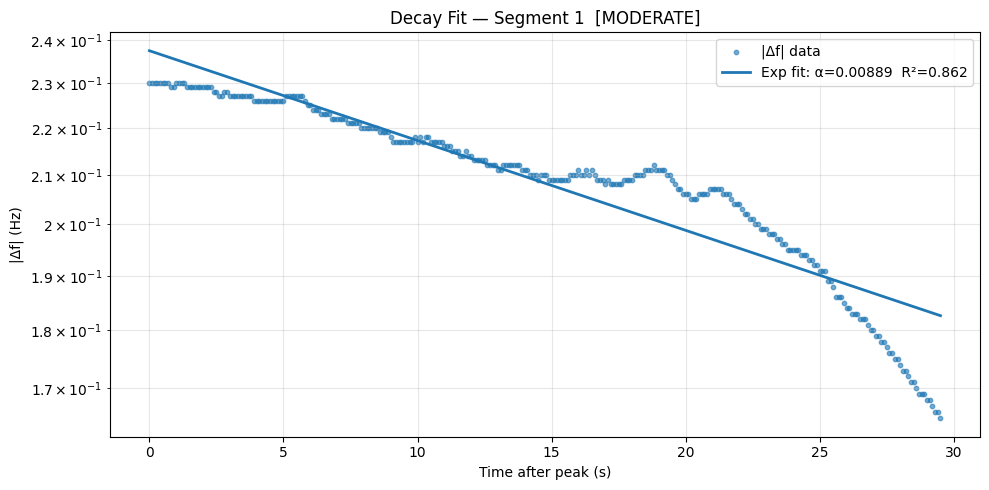

α = D/(2H) = 0.008894 1/s  |  R² = 0.8616

--- Decay fit: Event 2 ---


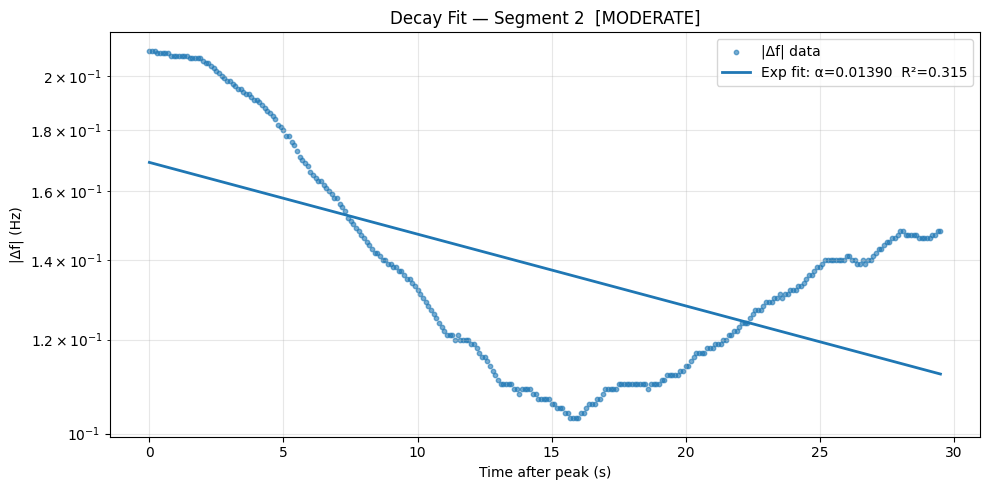

α = D/(2H) = 0.013902 1/s  |  R² = 0.3152

--- Decay fit: Event 3 ---


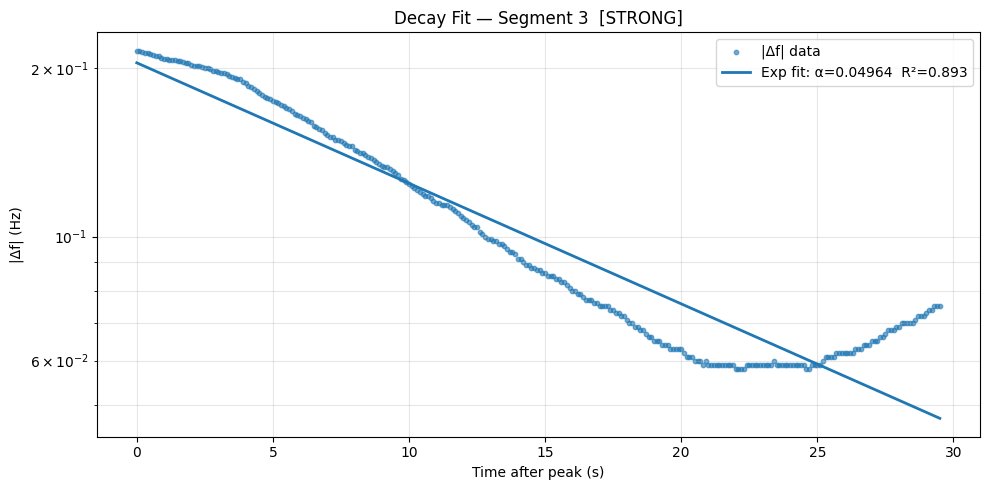

α = D/(2H) = 0.049636 1/s  |  R² = 0.8928


In [151]:
for i in range(len(segments_est)):
    print(f"\n--- Decay fit: Event {i} ---")
    plot_decay_fit(i)

In [152]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 10 — H AND D ESTIMATION VIA LEAST SQUARES (ΔP elimination)
#
# Physical basis:
#   In the inertial window (first INERTIAL_WINDOW_S after onset), ΔP is
#   approximately constant — the disturbance has occurred but governor
#   response has not yet acted (governor dead-band + delay ~ 2-10s).
#
#   The swing equation over N samples in this window:
#       2H * dΔf/dt[i] + D * Δf[i] = ΔP   for i = 1..N
#
#   This is a linear system: A @ [H, D]^T = ΔP * ones
#   where A[:, 0] = 2 * rocof,  A[:, 1] = delta_f
#
#   Least squares solution minimises ||A @ x - ΔP * 1||²
#   but since ΔP is also unknown, we solve the constrained system:
#       [2*rocof | delta_f | -1] @ [H, D, ΔP]^T = 0
#   i.e. homogeneous least squares → smallest singular value of
#   the matrix [2*rocof, delta_f, -ones]
#
# Consistency check: D/(2H) should match alpha from Section 9.
# ═══════════════════════════════════════════════════════════════════════════════
INERTIAL_WINDOW_S = 5.0   # seconds — governor dead-band; tune if needed

def estimate_H_D(segment_row, inertial_window_s=INERTIAL_WINDOW_S):
    """
    Estimate H and D for one event using homogeneous least squares
    over the inertial window after onset.

    Returns dict with H, D, ΔP, alpha_check, consistency, or None.
    """
    seg        = segments_est.iloc[segment_row]
    onset      = seg['onset_time']
    window_end = onset + pd.Timedelta(seconds=inertial_window_s)
    data       = df_reliable.loc[onset:window_end].copy()

    if len(data) < 10:
        return None

    rocof  = data['rocof_Hz_per_s'].values
    delta_f = data['delta_f_Hz'].values

    # Build matrix [2*rocof | delta_f | -1]
    # Homogeneous LS: find [H, D, ΔP] s.t. 2H*rocof + D*delta_f - ΔP ≈ 0
    A = np.column_stack([
        2 * rocof,          # coefficient of H
        delta_f,            # coefficient of D
        -np.ones(len(data)) # coefficient of ΔP (negative, moves to RHS)
    ])

    # SVD — solution is right singular vector corresponding to smallest SV
    _, s, Vt = np.linalg.svd(A, full_matrices=False)
    x = Vt[-1]   # [H, D, ΔP] up to a sign

    H, D, dP = x[0], x[1], x[2]

    # Fix sign: H must be positive (physical constraint)
    if H < 0:
        H, D, dP = -H, -D, -dP

    # Reject unphysical solutions
    if H <= 0 or H > 100:   # H typically 2–15 s for large grids
        return None
    if D < 0:
        return None

    # Consistency check: D/(2H) should match alpha from decay fit
    alpha_ls    = D / (2 * H)
    alpha_decay = None
    if not decay_results.empty:
        row = decay_results[decay_results['segment_id'] == segment_row]
        if not row.empty:
            alpha_decay = float(row['alpha'].iloc[0])

    consistency = None
    if alpha_decay is not None:
        consistency = abs(alpha_ls - alpha_decay) / alpha_decay * 100  # % difference

    return {
        'segment_id'   : segment_row,
        'H_s'          : round(H,           4),
        'D'            : round(D,            4),
        'dP_pu'        : round(dP,           5),
        'alpha_ls'     : round(alpha_ls,     5),   # D/(2H) from LS
        'alpha_decay'  : round(alpha_decay,  5) if alpha_decay else None,
        'consistency_pct': round(consistency, 1) if consistency else None,
        'n_samples'    : len(data),
        'classification': seg['classification'],
    }

HD_results = pd.DataFrame(
    [r for r in (estimate_H_D(i) for i in range(len(segments_est)))
     if r is not None]
)

print(f"\nH/D estimated for {len(HD_results)} / {len(segments_est)} segments:")
display(HD_results)

# Summary statistics across events
if len(HD_results) > 0:
    print("\n── Summary ──────────────────────────────────")
    print(f"  H  :  mean = {HD_results['H_s'].mean():.3f} s"
          f"  |  median = {HD_results['H_s'].median():.3f} s"
          f"  |  std = {HD_results['H_s'].std():.3f} s")
    print(f"  D  :  mean = {HD_results['D'].mean():.4f}"
          f"  |  median = {HD_results['D'].median():.4f}"
          f"  |  std = {HD_results['D'].std():.4f}")
    print(f"  α = D/(2H) check:")
    print(f"    from LS    : {HD_results['alpha_ls'].mean():.5f} 1/s")
    if HD_results['alpha_decay'].notna().any():
        print(f"    from decay : {HD_results['alpha_decay'].mean():.5f} 1/s")
    if HD_results['consistency_pct'].notna().any():
        print(f"    consistency: {HD_results['consistency_pct'].mean():.1f}% avg difference")


H/D estimated for 3 / 4 segments:


,segment_id,H_s,D,dP_pu,alpha_ls,alpha_decay,consistency_pct,n_samples,classification
0,0,0.9969,0.0673,0.03972,0.03376,0.02300,46.8,51,STRONG
1,1,0.9898,0.1392,0.02898,0.07030,0.00889,690.5,51,MODERATE
2,2,0.3612,0.9128,-0.19053,1.26358,0.01390,8989.4,51,MODERATE



── Summary ──────────────────────────────────
  H  :  mean = 0.783 s  |  median = 0.990 s  |  std = 0.365 s
  D  :  mean = 0.3731  |  median = 0.1392  |  std = 0.4688
  α = D/(2H) check:
    from LS    : 0.45588 1/s
    from decay : 0.01526 1/s
    consistency: 3242.2% avg difference


In [154]:
# Inspect the inertial window for each estimation-grade event
for i in range(len(segments_est)):
    seg    = segments_est.iloc[i]
    onset  = seg['onset_time']
    window = df_reliable.loc[onset : onset + pd.Timedelta(seconds=10)]

    print(f"\nEvent {i} — inertial window ({seg['classification']}):")
    print(f"  RoCoF range : {window['rocof_Hz_per_s'].min():.5f} to "
          f"{window['rocof_Hz_per_s'].max():.5f} Hz/s")
    print(f"  Δf range    : {window['delta_f_Hz'].min():.4f} to "
          f"{window['delta_f_Hz'].max():.4f} Hz")
    print(f"  RoCoF / Δf ratio (should vary widely if H/D separable): "
          f"{(window['rocof_Hz_per_s'].abs() / window['delta_f_Hz'].abs()).describe()}")



Event 0 — inertial window (STRONG):
  RoCoF range : 0.00273 to 0.02111 Hz/s
  Δf range    : 0.1100 to 0.2150 Hz
  RoCoF / Δf ratio (should vary widely if H/D separable): count    101.000000
mean       0.067596
std        0.045457
min        0.012690
25%        0.028956
50%        0.061145
75%        0.097001
max        0.160101
dtype: float64

Event 1 — inertial window (MODERATE):
  RoCoF range : 0.00416 to 0.00937 Hz/s
  Δf range    : 0.1100 to 0.1780 Hz
  RoCoF / Δf ratio (should vary widely if H/D separable): count    101.000000
mean       0.047942
std        0.009005
min        0.033275
25%        0.039616
50%        0.047764
75%        0.054009
max        0.067095
dtype: float64

Event 2 — inertial window (MODERATE):
  RoCoF range : -0.00420 to 0.01218 Hz/s
  Δf range    : -0.2110 to -0.1630 Hz
  RoCoF / Δf ratio (should vary widely if H/D separable): count    101.000000
mean       0.029797
std        0.023380
min        0.000097
25%        0.010949
50%        0.020450
75%       

/Users/macbookair/.local/share/virtualenvs/Frequency_Stability-v5D_102U/lib/python3.14/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
